In [1]:
%run ../../setup_workspace.py # ../ means level up 

# Three Phase Invariant

Δρ₁₂ (PNIPAM - PEG cr) = -0.078 e⁻/см³
Δρ₁₃ (PNIPAM - PEG am) = -0.002 e⁻/см³
Δρ₂₃ (PEG cr - PEG am) = 0.076 e⁻/см³


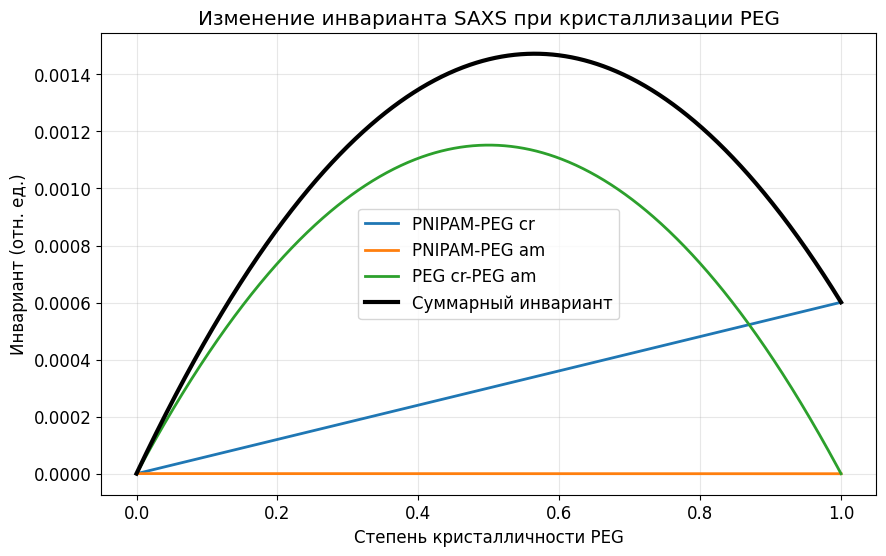


При cr=0: Z = 0.0000
При cr=1: Z = 0.0006
Изменение: 0.0006 (141702.4%)


In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Молярные массы (г/моль)
M_pnipam = 113.16
M_peg = 44.05

# Плотности (г/см³)
rho_pnipam = 1.1
rho_peg_cr = 1.25
rho_peg_am = 1.11

# Электронная плотность (e⁻/см³)
e_pnipam = rho_pnipam / M_pnipam * 62  # 62 e⁻ в мономере PNIPAM
e_peg_cr = rho_peg_cr / M_peg * 24    # 24 e⁻ в мономере PEG
e_peg_am = rho_peg_am / M_peg * 24

# Разности электронных плотностей
delta_rho_12 = e_pnipam - e_peg_cr   # PNIPAM - PEG крист
delta_rho_13 = e_pnipam - e_peg_am   # PNIPAM - PEG аморф
delta_rho_23 = e_peg_cr - e_peg_am   # PEG крист - PEG аморф

print(f"Δρ₁₂ (PNIPAM - PEG cr) = {delta_rho_12:.3f} e⁻/см³")
print(f"Δρ₁₃ (PNIPAM - PEG am) = {delta_rho_13:.3f} e⁻/см³")
print(f"Δρ₂₃ (PEG cr - PEG am) = {delta_rho_23:.3f} e⁻/см³")

# Параметры
phi_pnipam = 0.11  # объемная доля PNIPAM
cr = np.linspace(0, 1, 1000)  # степень кристалличности PEG

# Объемные доли фаз
phi_peg_total = 1 - phi_pnipam  # общая доля PEG
phi_peg_cr = cr * phi_peg_total      # кристаллический PEG
phi_peg_am = (1 - cr) * phi_peg_total  # аморфный PEG

# Инвариант (пропорциональный)
Z = (delta_rho_12**2 * phi_pnipam * phi_peg_cr +
     delta_rho_13**2 * phi_pnipam * phi_peg_am +
     delta_rho_23**2 * phi_peg_cr * phi_peg_am)

# Компоненты для анализа
Z12 = delta_rho_12**2 * phi_pnipam * phi_peg_cr
Z13 = delta_rho_13**2 * phi_pnipam * phi_peg_am
Z23 = delta_rho_23**2 * phi_peg_cr * phi_peg_am

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(cr, Z12, label='PNIPAM-PEG cr', linewidth=2)
plt.plot(cr, Z13, label='PNIPAM-PEG am', linewidth=2)
plt.plot(cr, Z23, label='PEG cr-PEG am', linewidth=2)
plt.plot(cr, Z, 'k-', linewidth=3, label='Суммарный инвариант')

plt.xlabel('Степень кристалличности PEG')
plt.ylabel('Инвариант (отн. ед.)')
plt.title('Изменение инварианта SAXS при кристаллизации PEG')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Анализ изменения
print(f"\nПри cr=0: Z = {Z[0]:.4f}")
print(f"При cr=1: Z = {Z[-1]:.4f}")
print(f"Изменение: {Z[-1]-Z[0]:.4f} ({100*(Z[-1]-Z[0])/Z[0]:.1f}%)")

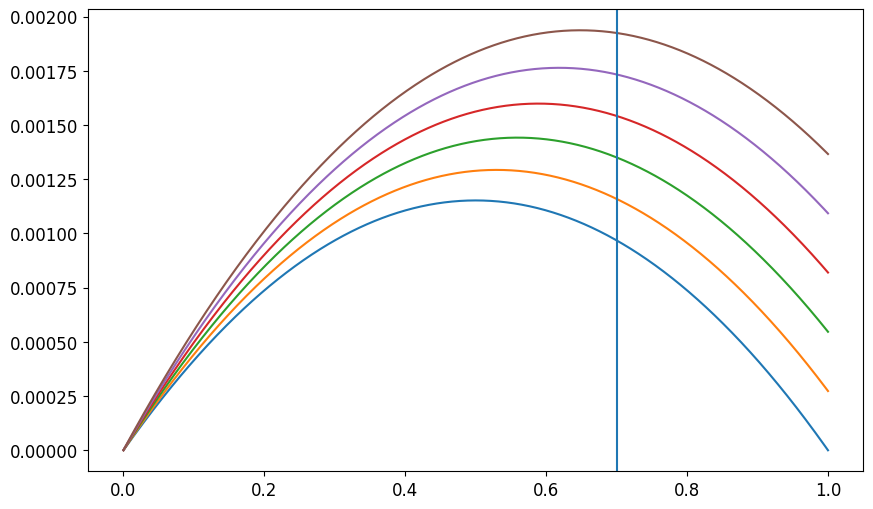

In [69]:
phi = 0.5

def rho(phi):
    rho1 = phi * phi_peg_cr * delta_rho_12 ** 2
    rho2 = phi * phi_peg_am * delta_rho_13 ** 2
    rho3 = phi_peg_cr * phi_peg_am * delta_rho_23 ** 2

    return rho1 + rho2 + rho3

for phi in [0, 0.05, 0.1, 0.15, 0.2, 0.25]:
    plt.plot(cr,rho(phi) )

plt.axvline(0.7)